In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import lightgbm as lgb
import optuna 

AttributeError: partially initialized module 'pandas' has no attribute '_pandas_datetime_CAPI' (most likely due to a circular import)

In [ ]:
df_raw = pd.read_csv("abalone.data.csv", sep = ',')
print(df_raw.head())

  gender  Length  Diameter  Height  Whole weight  Shucked weight  \
0      M   0.455     0.365   0.095        0.5140          0.2245   
1      M   0.350     0.265   0.090        0.2255          0.0995   
2      F   0.530     0.420   0.135        0.6770          0.2565   
3      M   0.440     0.365   0.125        0.5160          0.2155   
4      I   0.330     0.255   0.080        0.2050          0.0895   

   Viscera weight  Shell weight  Rings  
0          0.1010         0.150     15  
1          0.0485         0.070      7  
2          0.1415         0.210      9  
3          0.1140         0.155     10  
4          0.0395         0.055      7  


In [ ]:
df_na = df_raw.isna().sum()
print(df_na)

gender            0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64


In [ ]:
df_encoded = pd.get_dummies(df_raw)
df_encoded = df_encoded.drop(columns = 'gender_I')
print(df_encoded.head())

   Length  Diameter  Height  Whole weight  Shucked weight  Viscera weight  \
0   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell weight  Rings  gender_F  gender_M  
0         0.150     15     False      True  
1         0.070      7     False      True  
2         0.210      9      True     False  
3         0.155     10     False      True  
4         0.055      7     False     False  


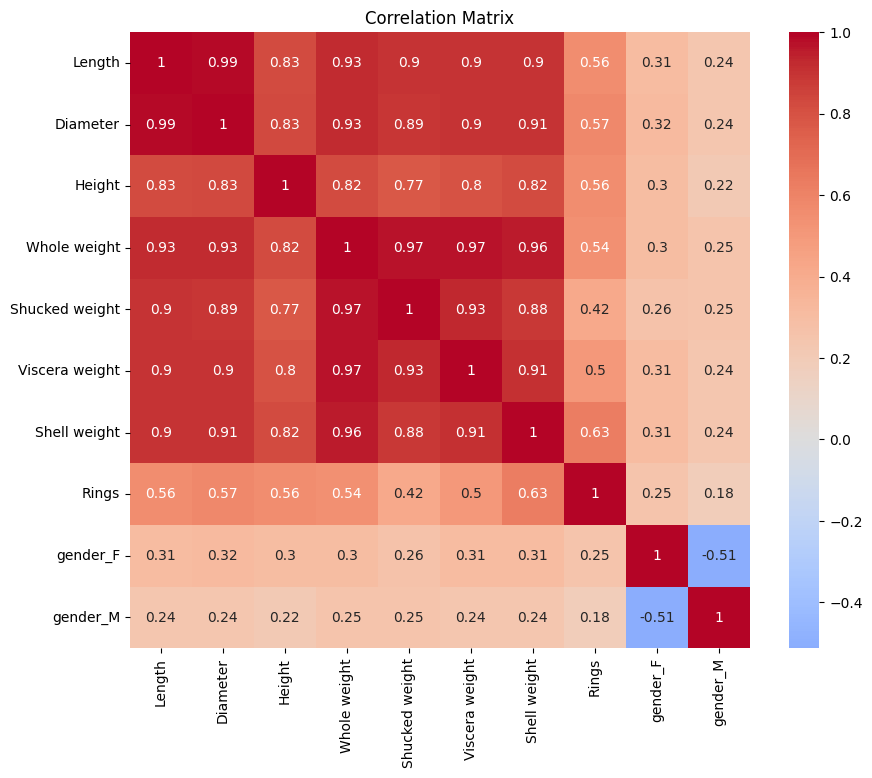

In [5]:
corr_matrix = df_encoded.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

df_training_data, df_testing_data = train_test_split(df_encoded, test_size=0.2, random_state = 42)

In [7]:
outcome = 'Rings'
predictors = [col for col in df_training_data.columns if col not in ('Rings', 'gender_F', 'gender_M')]

In [8]:

results = []

for i in range (0, 1000):

    df_train, df_test = train_test_split(df_training_data, test_size=0.2, random_state = i)
    model = LinearRegression().fit(df_train[predictors], df_train[outcome])
    
    total_test_pred = model.predict(df_test[predictors])

    results.append({
        'r2' : r2_score(df_test[outcome], total_test_pred),
        'mse' : mean_squared_error(df_test[outcome], total_test_pred),
        'Intercept' : model.intercept_,
        **{name : coef for name, coef in zip(predictors, model.coef_)}

    })

results_total = pd.DataFrame(results)

results_total.head()

,r2,mse,Intercept,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
0,0.486836,5.254144,3.029370,-0.942782,12.798330,10.726733,10.257701,-21.845406,-9.645678,7.541586
1,0.416903,5.988438,2.645559,-3.623995,12.882380,26.590788,9.555696,-20.178690,-11.061649,6.544143
2,0.507628,4.982071,3.057288,-1.597536,13.720607,9.856330,10.339040,-21.638769,-9.809769,7.172971
3,0.534929,4.301582,3.125705,-4.329042,16.892266,10.303112,9.473203,-21.058875,-8.919249,8.688206
4,0.453888,5.461582,2.705706,-2.088008,11.392528,24.595892,9.864093,-21.762323,-9.287608,6.616866


In [9]:
results_total.describe()

,r2,mse,Intercept,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.506579,5.037825,2.947887,-1.658149,13.311810,13.008668,9.172891,-20.563935,-8.999413,8.479350
std,0.045187,0.511878,0.201124,1.153520,1.600722,5.863411,0.707680,0.795849,1.047977,1.076330
min,0.330676,3.394686,2.341493,-5.207148,8.041676,8.472762,7.184154,-22.910591,-13.623814,4.983108
25%,0.487620,4.665678,2.840386,-2.399509,12.274465,9.896507,8.684068,-21.076997,-9.652474,7.753695
50%,0.515293,4.982527,2.991113,-1.670614,13.378297,10.319069,9.126108,-20.534737,-8.936190,8.538958
75%,0.537774,5.385257,3.086973,-0.923223,14.364560,10.967644,9.631012,-19.982096,-8.315744,9.204282
max,0.608749,6.746359,3.437517,2.427132,18.069014,32.479238,11.545205,-17.873136,-5.678976,11.758968


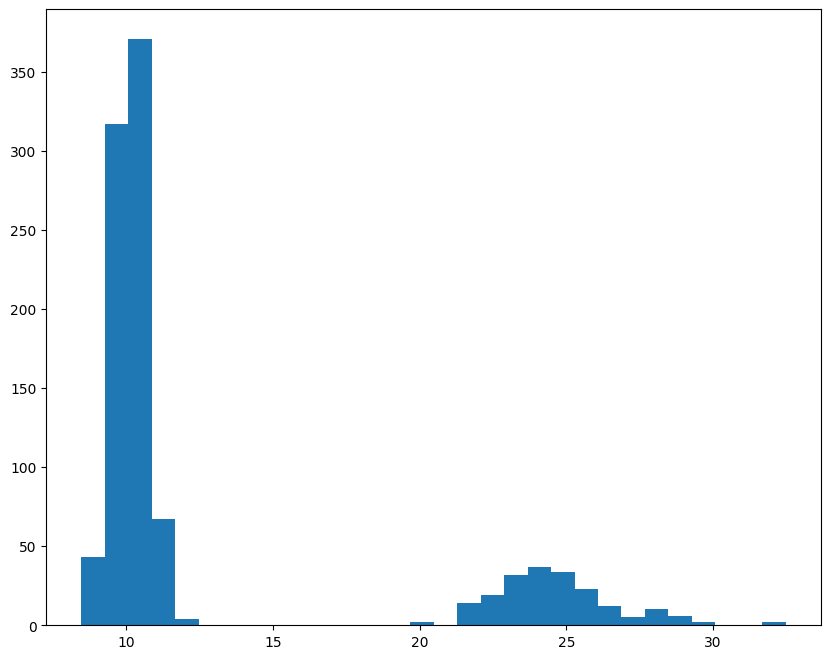

In [10]:
plt.figure(figsize=(10, 8))
plt.hist(results_total.Height, bins = 30)
plt.show()

Text(0.5, 1.0, 'Height vs rings, look for clusters')

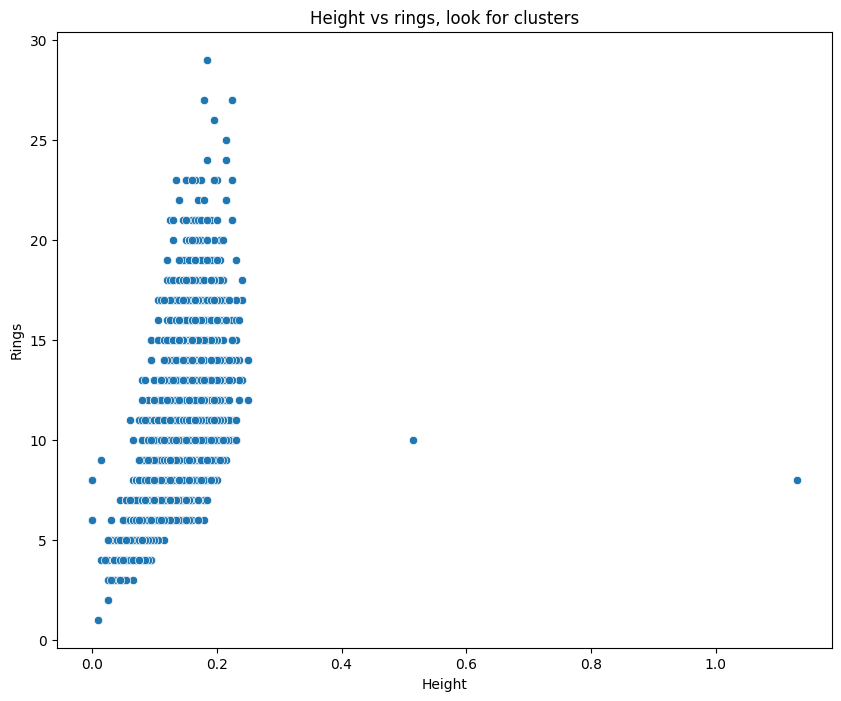

In [11]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x = 'Height', y = 'Rings', data = df_raw)
plt.title('Height vs rings, look for clusters')

(0.0, 0.4)

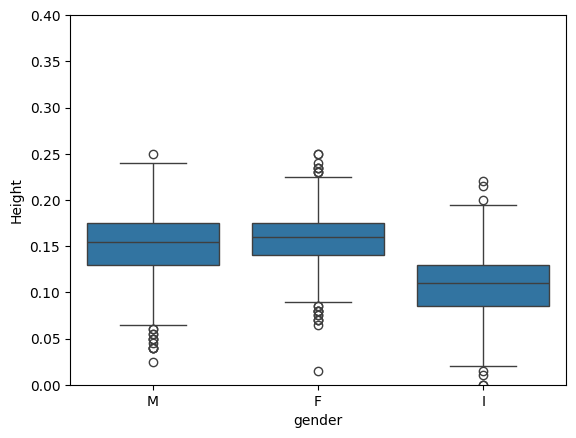

In [12]:
sns.boxplot(x='gender', y='Height', data=df_raw)
plt.ylim(0, 0.4)

Text(0.5, 1.0, 'Height vs Length - Outliers?')

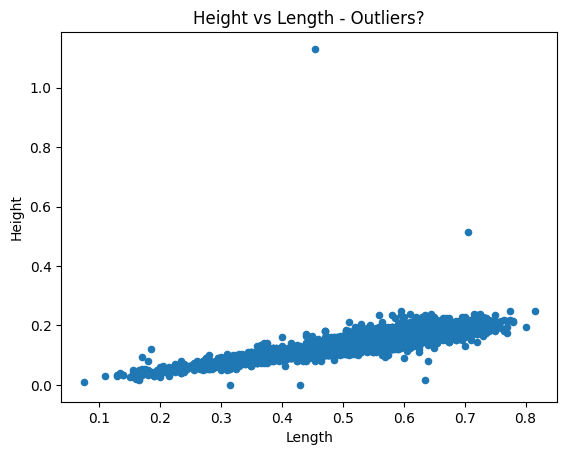

In [13]:
df_raw.plot.scatter(x='Length', y='Height')
plt.title('Height vs Length - Outliers?')

In [14]:
df_infant_raw = df_raw.where(df_raw.gender == 'I').dropna()
df_infant_raw = df_infant_raw.drop(columns = 'gender')
df_infant_raw.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7.0
5,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.120,8.0
16,0.355,0.280,0.085,0.2905,0.0950,0.0395,0.115,7.0
21,0.380,0.275,0.100,0.2255,0.0800,0.0490,0.085,10.0
42,0.240,0.175,0.045,0.0700,0.0315,0.0235,0.020,5.0


In [15]:
df_training_data_i, df_testing_data_i = train_test_split(df_infant_raw, test_size=0.2, random_state = 42)
predictors = [col for col in df_training_data_i.columns if col not in ('Rings')]

In [16]:
results_i = []

for i in range (0, 1000):

    df_train_i, df_test_i = train_test_split(df_training_data_i, test_size=0.2)
    model_i = LinearRegression().fit(df_train_i[predictors], df_train_i[outcome])
    
    y_pred_i = model_i.predict(df_test_i[predictors])

    results_i.append({
        'r2' : r2_score(df_test_i[outcome], y_pred_i),
        'mse' : mean_squared_error(df_test_i[outcome], y_pred_i),
        'Intercept' : model.intercept_,
        **{name : coef for name, coef in zip(predictors, model.coef_)}

    })

results_i_total = pd.DataFrame(results_i)

results_i_total.describe()

,r2,mse,Intercept,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
count,1000.000000,1000.000000,1.000000e+03,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000
mean,0.553378,2.706847,3.315548e+00,-2.278978,1.329589e+01,1.044432e+01,9.670743e+00,-21.411754,-9.946956,10.103748
std,0.053985,0.450242,1.332934e-15,0.000000,1.777246e-15,1.777246e-15,1.777246e-15,0.000000,0.000000,0.000000
min,0.287967,1.513290,3.315548e+00,-2.278978,1.329589e+01,1.044432e+01,9.670743e+00,-21.411754,-9.946956,10.103748
25%,0.521774,2.399178,3.315548e+00,-2.278978,1.329589e+01,1.044432e+01,9.670743e+00,-21.411754,-9.946956,10.103748
50%,0.557177,2.696197,3.315548e+00,-2.278978,1.329589e+01,1.044432e+01,9.670743e+00,-21.411754,-9.946956,10.103748
75%,0.589557,3.006536,3.315548e+00,-2.278978,1.329589e+01,1.044432e+01,9.670743e+00,-21.411754,-9.946956,10.103748
max,0.716581,4.158830,3.315548e+00,-2.278978,1.329589e+01,1.044432e+01,9.670743e+00,-21.411754,-9.946956,10.103748


In [17]:
results_i_total.head()

,r2,mse,Intercept,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
0,0.557584,3.439156,3.315548,-2.278978,13.295887,10.444319,9.670743,-21.411754,-9.946956,10.103748
1,0.585541,2.212801,3.315548,-2.278978,13.295887,10.444319,9.670743,-21.411754,-9.946956,10.103748
2,0.546066,2.595195,3.315548,-2.278978,13.295887,10.444319,9.670743,-21.411754,-9.946956,10.103748
3,0.543349,2.438148,3.315548,-2.278978,13.295887,10.444319,9.670743,-21.411754,-9.946956,10.103748
4,0.507190,3.022467,3.315548,-2.278978,13.295887,10.444319,9.670743,-21.411754,-9.946956,10.103748


In [18]:
df_mature_raw = df_raw.where(df_raw.gender != 'I').dropna()
df_mature = pd.get_dummies(df_mature_raw)
df_mature  = df_mature.drop(columns = 'gender_M')
df_mature.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,gender_F
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15.0,False
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7.0,False
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9.0,True
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10.0,False
6,0.530,0.415,0.150,0.7775,0.2370,0.1415,0.330,20.0,True


In [ ]:
df_training_data_m, df_testing_data_m = train_test_split(df_mature, test_size=0.2, random_state = 45)
predictors = [col for col in df_training_data_m.columns if col not in ('Rings')]


In [20]:
results_m = []

for i in range (0, 1000):

    df_train_m, df_test_m = train_test_split(df_training_data_m, test_size=0.2)
    model_m = LinearRegression().fit(df_train_m[predictors], df_train_m[outcome])
    
    total_test_pred = model_m.predict(df_test_m[predictors])

    results_m.append({
        'r2' : r2_score(df_test_m[outcome], total_test_pred),
        'mse' : mean_squared_error(df_test_m[outcome], total_test_pred),
        'Intercept' : model.intercept_,
        **{name : coef for name, coef in zip(predictors, model.coef_)}

    })

results_m_total = pd.DataFrame(results_m)

results_m_total.describe()

,r2,mse,Intercept,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
count,1000.000000,1000.000000,1.000000e+03,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000
mean,0.375095,6.027266,3.315548e+00,-2.278978,1.329589e+01,1.044432e+01,9.670743e+00,-21.411754,-9.946956,10.103748
std,0.043807,0.551335,1.332934e-15,0.000000,1.777246e-15,1.777246e-15,1.777246e-15,0.000000,0.000000,0.000000
min,0.200644,4.354739,3.315548e+00,-2.278978,1.329589e+01,1.044432e+01,9.670743e+00,-21.411754,-9.946956,10.103748
25%,0.348997,5.645937,3.315548e+00,-2.278978,1.329589e+01,1.044432e+01,9.670743e+00,-21.411754,-9.946956,10.103748
50%,0.379961,6.024133,3.315548e+00,-2.278978,1.329589e+01,1.044432e+01,9.670743e+00,-21.411754,-9.946956,10.103748
75%,0.404817,6.392436,3.315548e+00,-2.278978,1.329589e+01,1.044432e+01,9.670743e+00,-21.411754,-9.946956,10.103748
max,0.495420,7.722406,3.315548e+00,-2.278978,1.329589e+01,1.044432e+01,9.670743e+00,-21.411754,-9.946956,10.103748


In [21]:
total_test_pred = model_m.predict(df_testing_data[predictors])
r2 = r2_score(df_testing_data[outcome], total_test_pred)
mse = mean_squared_error(df_testing_data[outcome], total_test_pred)
print(r2, mse)


0.4823401051891373 5.603777093488824


Text(0.5, 1.0, 'Predictions vs Actuals')

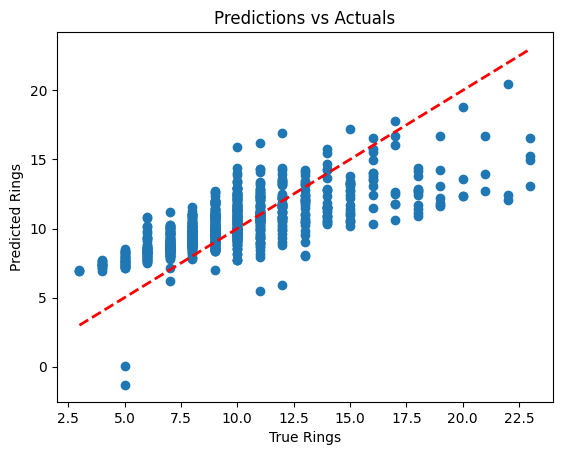

In [22]:
plt.scatter(df_testing_data[outcome], total_test_pred)
plt.plot([df_testing_data[outcome].min(), df_testing_data[outcome].max()], [df_testing_data[outcome].min(), df_testing_data[outcome].max()], 'r--', lw=2)
plt.xlabel('True Rings')
plt.ylabel('Predicted Rings')
plt.title('Predictions vs Actuals')

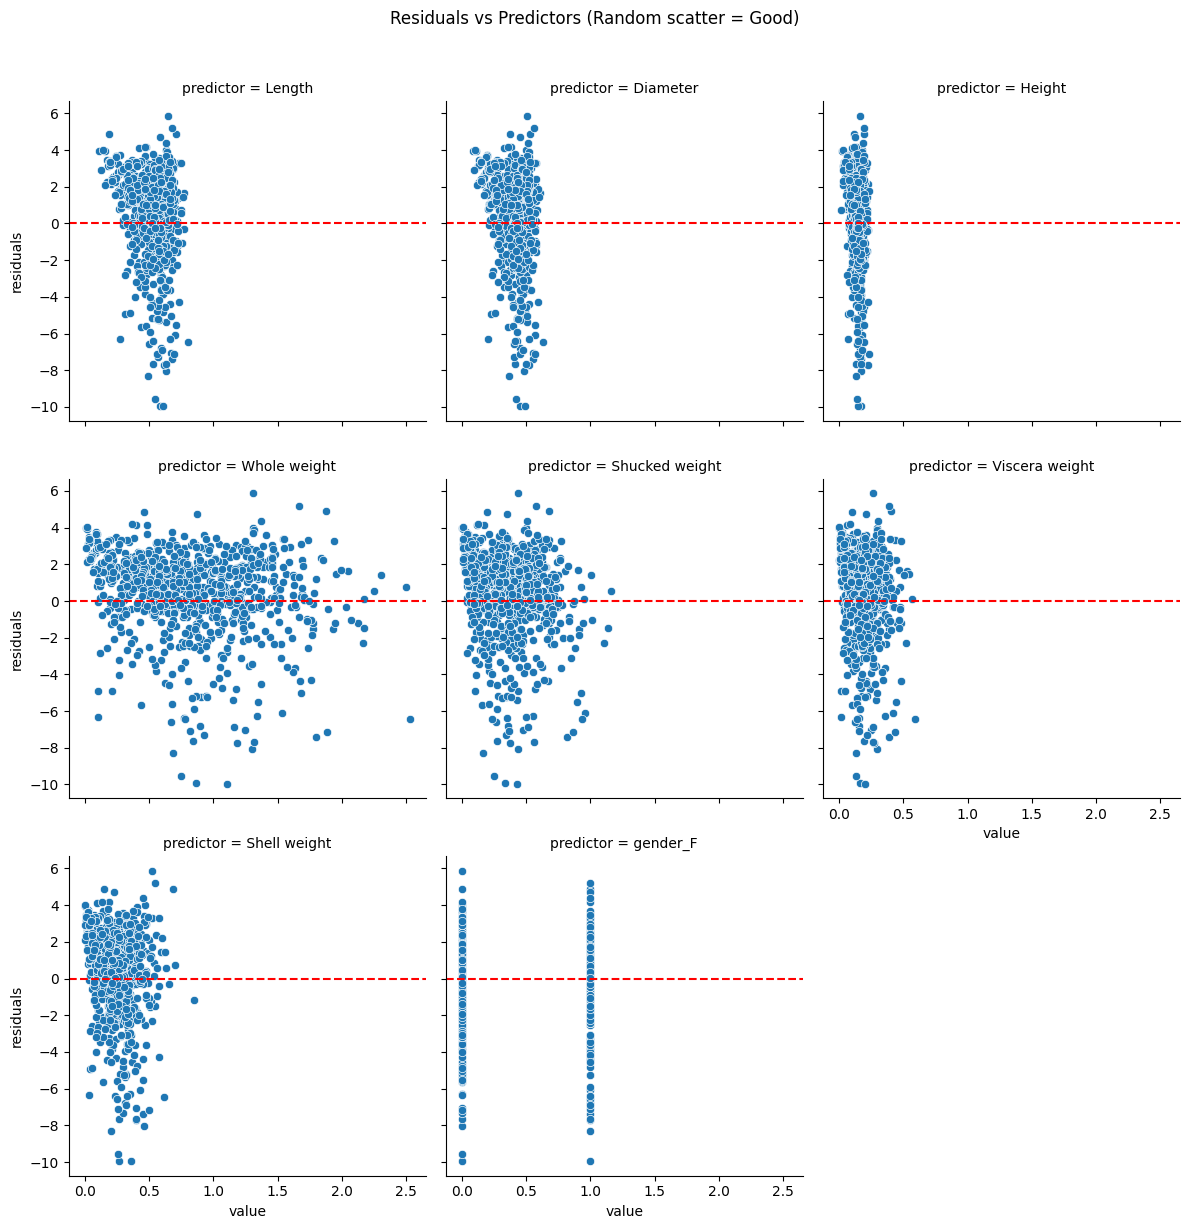

In [23]:
residuals_df = pd.DataFrame({
    'residuals': total_test_pred - df_testing_data[outcome],  # Or your test residuals
    **{col: df_testing_data[col].values for col in predictors}  # 7 predictors
}).melt(id_vars=['residuals'], var_name='predictor', value_name='value')

# Build facet grid (auto-arranges 7 panels)
g = sns.FacetGrid(residuals_df, col='predictor', col_wrap=3, height=4)
g.map(sns.scatterplot, 'value', 'residuals')
g.map(plt.axhline, y=0, color='red', ls='--')  # Zero line per panel
g.figure.suptitle('Residuals vs Predictors (Random scatter = Good)', y=1.02)
plt.tight_layout()
plt.show()

In [1]:

from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler

df_encoded_full = pd.get_dummies(df_raw)
"""
y = df_encoded_full['Rings']
X = df_encoded_full.drop(columns = 'Rings')
"""
y = df_encoded_full['Rings']
X = df_encoded_full.drop(columns = 'Rings')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

num_round = 200

KeyboardInterrupt: 

In [ ]:
"""X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train = np.log1p(y_train)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, np.log1p(y_test))],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

y_pred = np.expm1(lgb_model.predict(X_test))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.4f}, R²: {r2:.4f}")

# Plot predictions
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True Rings'); plt.ylabel('Predicted')
plt.title(f'LightGBM (R²={r2:.3f})')
plt.show()
"""

'X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)\n\nscaler = StandardScaler()\nX_train = scaler.fit_transform(X_train)\nX_test = scaler.transform(X_test)\n\ny_train = np.log1p(y_train)\n\nlgb_model.fit(\n    X_train, y_train,\n    eval_set=[(X_test, np.log1p(y_test))],\n    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]\n)\n\ny_pred = np.expm1(lgb_model.predict(X_test))\nrmse = np.sqrt(mean_squared_error(y_test, y_pred))\nr2 = r2_score(y_test, y_pred)\nprint(f"RMSE: {rmse:.4f}, R²: {r2:.4f}")\n\n# Plot predictions\nplt.scatter(y_test, y_pred, alpha=0.6)\nplt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], \'r--\')\nplt.xlabel(\'True Rings\'); plt.ylabel(\'Predicted\')\nplt.title(f\'LightGBM (R²={r2:.3f})\')\nplt.show()\n'

In [ ]:
def objective(trial):
    # Hyperparameter search space
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        'random_state': 42,
        'verbose': -1
    }

    # Train/validation on your existing split
    model_inner = lgb.LGBMRegressor(
        n_estimators=1000,
        **params
    )
    model_inner.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    y_pred = model_inner.predict(X_test, num_iteration=model_inner.best_iteration_)
    return r2_score(y_test, y_pred)  # maximize R² on raw Rings


# Run Optuna optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best R² on validation:", study.best_value)
print("Best params:", study.best_params)

[I 2026-01-22 02:00:27,510] A new study created in memory with name: no-name-d97d2ab2-4d61-4f73-8531-4080bc4e5053
  0%|          | 0/50 [00:00<?, ?it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 0. Best value: 0.382306:   0%|          | 0/50 [00:00<?, ?it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 0. Best value: 0.382306:   4%|▍         | 2/50 [00:00<00:02, 18.81it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 0. Best valu

[I 2026-01-22 02:00:27,579] Trial 0 finished with value: 0.3823061905223091 and parameters: {'num_leaves': 138, 'learning_rate': 0.04536462537838746, 'feature_fraction': 0.8808860053953733, 'bagging_fraction': 0.6238475265448646, 'bagging_freq': 5, 'min_child_samples': 25, 'reg_alpha': 2.0593968044645754, 'reg_lambda': 3.76710841027461}. Best is trial 0 with value: 0.3823061905223091.
[I 2026-01-22 02:00:27,616] Trial 1 finished with value: 0.3722136259428792 and parameters: {'num_leaves': 44, 'learning_rate': 0.18341261822993676, 'feature_fraction': 0.6236059747002168, 'bagging_fraction': 0.6241648982881652, 'bagging_freq': 5, 'min_child_samples': 44, 'reg_alpha': 0.9964766857140939, 'reg_lambda': 4.492938398567211}. Best is trial 0 with value: 0.3823061905223091.
[I 2026-01-22 02:00:27,684] Trial 2 finished with value: 0.37455557286791374 and parameters: {'num_leaves': 145, 'learning_rate': 0.09451340573081521, 'feature_fraction': 0.6201861976447621, 'bagging_fraction': 0.90113491808

Best trial: 3. Best value: 0.388347:   8%|▊         | 4/50 [00:00<00:03, 14.09it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 3. Best value: 0.388347:   8%|▊         | 4/50 [00:00<00:03, 14.09it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 3. Best value: 0.388347:  10%|█         | 5/50 [00:00<00:03, 14.09it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 3. Best value: 0.388347:  14%|█▍        | 7/50 [00:00<00:02, 16.32it/s]

[I 2026-01-22 02:00:27,779] Trial 3 finished with value: 0.3883469634775629 and parameters: {'num_leaves': 54, 'learning_rate': 0.06959512745940268, 'feature_fraction': 0.7081497164214723, 'bagging_fraction': 0.926495208580325, 'bagging_freq': 2, 'min_child_samples': 31, 'reg_alpha': 3.4847739692814166, 'reg_lambda': 4.944279494836975}. Best is trial 3 with value: 0.3883469634775629.
[I 2026-01-22 02:00:27,831] Trial 4 finished with value: 0.3795460218561755 and parameters: {'num_leaves': 52, 'learning_rate': 0.135788196637668, 'feature_fraction': 0.8247387612208293, 'bagging_fraction': 0.8033100288787076, 'bagging_freq': 4, 'min_child_samples': 39, 'reg_alpha': 0.6150519965685319, 'reg_lambda': 4.919303455121055}. Best is trial 3 with value: 0.3883469634775629.
[I 2026-01-22 02:00:27,873] Trial 5 finished with value: 0.3754153509447613 and parameters: {'num_leaves': 37, 'learning_rate': 0.13884273252399293, 'feature_fraction': 0.6222895666412828, 'bagging_fraction': 0.682431723859496,

c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 3. Best value: 0.388347:  14%|█▍        | 7/50 [00:00<00:02, 16.32it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 3. Best value: 0.388347:  18%|█▊        | 9/50 [00:00<00:02, 14.36it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 3. Best value: 0.388347:  18%|█▊        | 9/50 [00:00<00:02, 14.36it/s]

...

[I 2026-01-22 02:00:33,164] Trial 42 finished with value: 0.38320303854958493 and parameters: {'num_leaves': 42, 'learning_rate': 0.04310879734669877, 'feature_fraction': 0.6202901699761955, 'bagging_fraction': 0.7326454297882504, 'bagging_freq': 2, 'min_child_samples': 29, 'reg_alpha': 0.9027760818311421, 'reg_lambda': 1.3501144852578149}. Best is trial 38 with value: 0.3961472521927325.
[I 2026-01-22 02:00:33,260] Trial 43 finished with value: 0.38741086272413605 and parameters: {'num_leaves': 30, 'learning_rate': 0.02765538391993127, 'feature_fraction': 0.9987734459302477, 'bagging_fraction': 0.7845716958269532, 'bagging_freq': 5, 'min_child_samples': 14, 'reg_alpha': 2.3856146533343097, 'reg_lambda': 1.1290586643522815}. Best is trial 38 with value: 0.3961472521927325.


Best trial: 38. Best value: 0.396147:  90%|█████████ | 45/50 [00:05<00:00,  8.81it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 38. Best value: 0.396147:  90%|█████████ | 45/50 [00:05<00:00,  8.81it/s]

[I 2026-01-22 02:00:33,375] Trial 44 finished with value: 0.38787863110177245 and parameters: {'num_leaves': 48, 'learning_rate': 0.03210614753606397, 'feature_fraction': 0.6355328137806823, 'bagging_fraction': 0.8168592722445845, 'bagging_freq': 2, 'min_child_samples': 21, 'reg_alpha': 1.926480711099891, 'reg_lambda': 1.7894539197876111}. Best is trial 38 with value: 0.3961472521927325.
[I 2026-01-22 02:00:33,467] Trial 45 finished with value: 0.3811091178027335 and parameters: {'num_leaves': 37, 'learning_rate': 0.03777828896730814, 'feature_fraction': 0.6548004900228009, 'bagging_fraction': 0.7364402684323494, 'bagging_freq': 7, 'min_child_samples': 23, 'reg_alpha': 1.616965590424512, 'reg_lambda': 0.7732790357574402}. Best is trial 38 with value: 0.3961472521927325.


c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 38. Best value: 0.396147:  94%|█████████▍| 47/50 [00:06<00:00,  7.63it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 38. Best value: 0.396147:  94%|█████████▍| 47/50 [00:06<00:00,  7.63it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 38. Best value: 0.396147:  98%|█████████▊| 49/50 [00:06<00:00,  9.51it/s]c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklear

[I 2026-01-22 02:00:33,705] Trial 46 finished with value: 0.38896527916511403 and parameters: {'num_leaves': 124, 'learning_rate': 0.01646267605891637, 'feature_fraction': 0.7007681647983154, 'bagging_fraction': 0.8326087312023114, 'bagging_freq': 2, 'min_child_samples': 14, 'reg_alpha': 1.2722481307546332, 'reg_lambda': 1.5270086969284224}. Best is trial 38 with value: 0.3961472521927325.
[I 2026-01-22 02:00:33,758] Trial 47 finished with value: 0.39368788903346663 and parameters: {'num_leaves': 28, 'learning_rate': 0.19499040485269356, 'feature_fraction': 0.8571255860418898, 'bagging_fraction': 0.8517785265499113, 'bagging_freq': 3, 'min_child_samples': 28, 'reg_alpha': 0.4904296448172003, 'reg_lambda': 1.7881194537823206}. Best is trial 38 with value: 0.3961472521927325.
[I 2026-01-22 02:00:33,807] Trial 48 finished with value: 0.37848421587891146 and parameters: {'num_leaves': 30, 'learning_rate': 0.15368947076461723, 'feature_fraction': 0.8604298580195737, 'bagging_fraction': 0.79

Training until validation scores don't improve for 50 rounds


c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[100]	valid_0's rmse: 2.53628
Early stopping, best iteration is:
[129]	valid_0's rmse: 2.51863
RMSE: 2.5186, R²: 0.3961


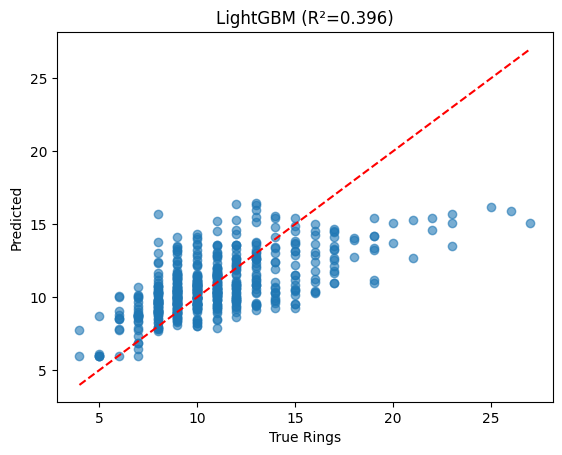

In [ ]:

best_params = study.best_params

best_params.update({
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'random_state': 42,
    'verbose': -1
})

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    **best_params
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

y_pred = lgb_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.4f}, R²: {r2:.4f}")

# Plot predictions
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True Rings'); plt.ylabel('Predicted')
plt.title(f'LightGBM (R²={r2:.3f})')
plt.show()